### Description de MNIST "Handwritten Digit Recognition Problem"

MNIST est un jeu de données développé par Yann LeCun, Corinna Cortes et Christopher Burges pour évaluer les modèles d’apprentissage automatique sur la classification des chiffres manuscrits.

Ce jeu de données a été construit à partir de plusieurs ensembles de documents numérisés provenant du National Institute of Standards and Technology (NIST). Nommé **Modified NIST**, ou **MNIST**.

Chaque image est un carré de **28×28 pixels** (soit **784 pixels** au total). Une division standard du jeu de données est utilisée pour l'évaluation et la comparaison des modèles : **60 000 images** servent à l'entraînement du modèle, et un ensemble distinct de **10 000 images** est utilisé pour le tester.

Il s'agit d'une tâche de reconnaissance de chiffres. Il y a donc **dix chiffres** (de 0 à 9), soit **dix classes** à prédire. 

Voici le schéma d’architecture des réseaux de neurones que nous allons réaliser dans ce workshop. 

<img src="Image1.png" width="900">

Import dependencies

In [6]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import os

1. Charger la dataset MNIST

In [7]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print(f"forme des images {x_train.shape}")  

forme des images (60000, 28, 28)


Pour commencer, nous devons spécifier quelques paramètres pour l'apprentissage:
<ul>
    <li>La longueur et la largeur des images. </li>
    <li>La taille du batch.</li>
</ul>

In [8]:
image_h, image_w = x_train.shape[1], x_train.shape[2]
batch_s = 32

2. Data processing :Normalisation des images (mise à l'échelle entre 0 et 1)

In [9]:
x_train, x_test = x_train / 255.0, x_test / 255.0

3. Construire les modèles

In [10]:
def build_small_model(): # create small model
    model = Sequential([
        layers.Input(shape=(image_h, image_w, 1)),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.Flatten(),
        layers.Dense(10, activation='softmax')
    ])
    return model

def build_medium_model(): # create medium model
    model = Sequential([
        layers.Input(shape=(image_h, image_w, 1)),
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(15, (3,3), activation='relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.2),
        layers.Flatten(),
        layers.Dense(64, activation='softmax'),
        layers.Dense(10, activation='softmax')
    ])
    return model

def build_large_model(): # create large model
    model = Sequential([
        layers.Input(shape=(image_h, image_w, 1)),
        layers.Conv2D(30, (3,3), activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(15, (3,3), activation='relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.2),
        layers.Flatten(),
        layers.Dense(128, activation='softmax'),
        layers.Dense(50, activation='softmax'),
        layers.Dense(10, activation='softmax')
    ])
    return model

4. Entraîner les modèles

In [11]:
models = {"small": build_small_model(), "medium": build_medium_model(), "large": build_large_model()}
histories = {}

SAVE_DIR = "mnist_results"
os.makedirs(SAVE_DIR, exist_ok=True)

for name, model in models.items():
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))
    histories[name] = history.history
    model.save(os.path.join(SAVE_DIR, f"{name}_model.h5"))
    np.save(os.path.join(SAVE_DIR, f"{name}_history.npy"), history.history)




Epoch 1/10


1875/1875 [==============================] - 34s 18ms/step - loss: 0.1249 - accuracy: 0.9622 - val_loss: 0.0613 - val_accuracy: 0.9805
Epoch 2/10
1875/1875 [==============================] - 32s 17ms/step - loss: 0.0452 - accuracy: 0.9861 - val_loss: 0.0438 - val_accuracy: 0.9857
Epoch 3/10
1875/1875 [==============================] - 31s 16ms/step - loss: 0.0298 - accuracy: 0.9909 - val_loss: 0.0468 - val_accuracy: 0.9862
Epoch 4/10
1875/1875 [==============================] - 30s 16ms/step - loss: 0.0201 - accuracy: 0.9931 - val_loss: 0.0487 - val_accuracy: 0.9856
Epoch 5/10
1875/1875 [==============================] - 32s 17ms/step - loss: 0.0149 - accuracy: 0.9951 - val_loss: 0.0486 - val_accuracy: 0.9864
Epoch 6/10
1875/1875 [==============================] - 32s 17ms/step - loss: 0.0103 - accuracy: 0.9966 - val_loss: 0.0595 - val_accuracy: 0.9854
Epoch 7/10
1875/1875 [==============================] - 30s 16ms/step - loss: 0.0082 - accuracy: 0.9971 - val_loss: 0.0

c:\Users\gbencheikh\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 1/10
1875/1875 [==============================] - 14s 7ms/step - loss: 1.1915 - accuracy: 0.8012 - val_loss: 0.5638 - val_accuracy: 0.8774
Epoch 2/10
1875/1875 [==============================] - 13s 7ms/step - loss: 0.4355 - accuracy: 0.8753 - val_loss: 0.3075 - val_accuracy: 0.8839
Epoch 3/10
1875/1875 [==============================] - 13s 7ms/step - loss: 0.2910 - accuracy: 0.8910 - val_loss: 0.2379 - val_accuracy: 0.9230
Epoch 4/10
1875/1875 [==============================] - 11s 6ms/step - loss: 0.2352 - accuracy: 0.9262 - val_loss: 0.1789 - val_accuracy: 0.9622
Epoch 5/10
1875/1875 [==============================] - 12s 6ms/step - loss: 0.1709 - accuracy: 0.9645 - val_loss: 0.1212 - val_accuracy: 0.9787
Epoch 6/10
1875/1875 [==============================] - 12s 7ms/step - loss: 0.1203 - accuracy: 0.9757 - val_loss: 0.0780 - val_accuracy: 0.9850
Epoch 7/10
1875/1875 [==============================] - 12s 6ms/step - loss: 0.0853 - accuracy: 0.9809 - val_loss: 0.0683 - val_ac

5. Validation : Plot Accuracy & Loss

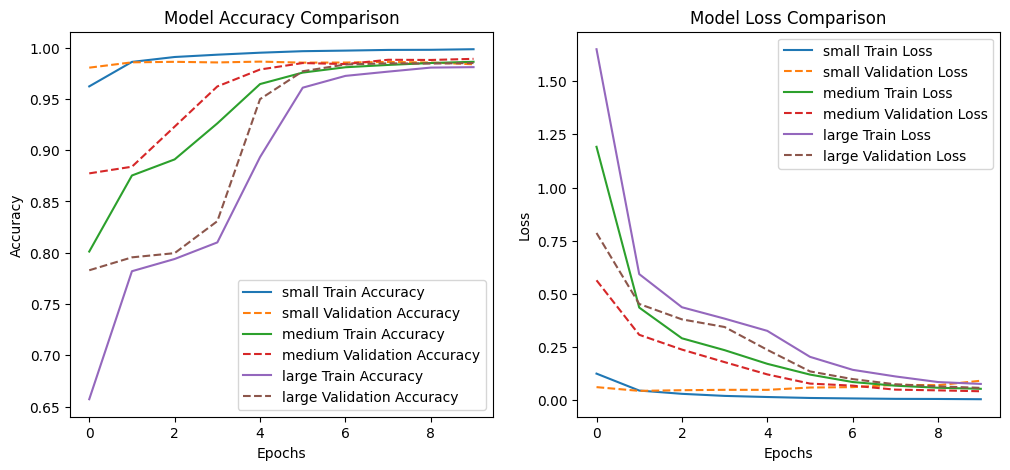

In [12]:
# Plot Accuracy & Loss for all models
def plot_all_metrics(histories):
    plt.figure(figsize=(12,5))
    
    # Accuracy Plot
    plt.subplot(1,2,1)
    for name, history in histories.items():
        plt.plot(history['accuracy'], label=f'{name} Train Accuracy')
        plt.plot(history['val_accuracy'], label=f'{name} Validation Accuracy', linestyle='dashed')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Model Accuracy Comparison')
    
    # Loss Plot
    plt.subplot(1,2,2)
    for name, history in histories.items():
        plt.plot(history['loss'], label=f'{name} Train Loss')
        plt.plot(history['val_loss'], label=f'{name} Validation Loss', linestyle='dashed')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Model Loss Comparison')
    
    plt.savefig(os.path.join(SAVE_DIR, "models_accuracy_loss_plot.png"))
    plt.show()

plot_all_metrics(histories)

In [13]:
results = {}
for name, model in models.items():
    scores = model.evaluate(x_test, y_test, verbose=0)
    results[name] = {"accuracy": scores[1] * 100, "error_rate": 100 - scores[1] * 100}

print(results)

{'small': {'accuracy': 98.37999939918518, 'error_rate': 1.6200006008148193}, 'medium': {'accuracy': 98.90999794006348, 'error_rate': 1.0900020599365234}, 'large': {'accuracy': 98.50000143051147, 'error_rate': 1.4999985694885254}}


### Analyse comparative des optimizers pour MNIST

Nous avons utilisé 'Adam' comme algorithme d’optimisation. Cependant, d’autres optimizers peuvent avoir un impact différent sur la convergence et la précision du modèle. Testez au moins trois autres optimizers parmi les suivants :

In [ ]:
# Liste tous les optimizers disponibles dans TensorFlow
optimizers = [opt for opt in dir(tf.keras.optimizers) if not opt.startswith("__")]
print(optimizers)

In [ ]:
# Executer cette ligne pour voir la documentation de chaque optimizer
help(tf.keras.optimizers.Adam)

1. Comparez leurs performances en traçant les courbes de perte et d’accuracy sur l’ensemble d'entraînement et de validation.

2. Analysez la vitesse de convergence et la précision finale de chaque optimizer.

3. Quel optimizer semble le plus efficace pour ce problème et pourquoi ?